# Carregament inicial del conjunt de dades

Es carrega el conjunt `df_preparat.csv`, que s’utilitza com a base per generar les anàlisis addicionals recollides en aquest annex.


In [1]:
import pandas as pd

# Carreguem el dataset final ja netejat i transformat, preparat per ser utilitzat en les diferents anàlisis del projecte
df = pd.read_csv("../data/df_preparat.csv")


# Comprovació de l’ordre aparent de les categories

En alguns gràfics del cos principal del treball, les categories semblaven aparèixer amb un ordre repetit.  
Aquest apartat explora si existeix realment un patró en l’ordre de les categories o si es tracta d’una coincidència deguda a l’ordenació alfabètica o a l’ordre original de les columnes.  
Després d’analitzar la coocurrència i ordenar per ús, es conclou que no hi ha cap significat rellevant en aquest ordre.


C:\Users\david\AppData\Local\Temp\ipykernel_13940\3153749707.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matriu_client_categoria = matriu_client_categoria.applymap(lambda x: 1 if x > 0 else 0)


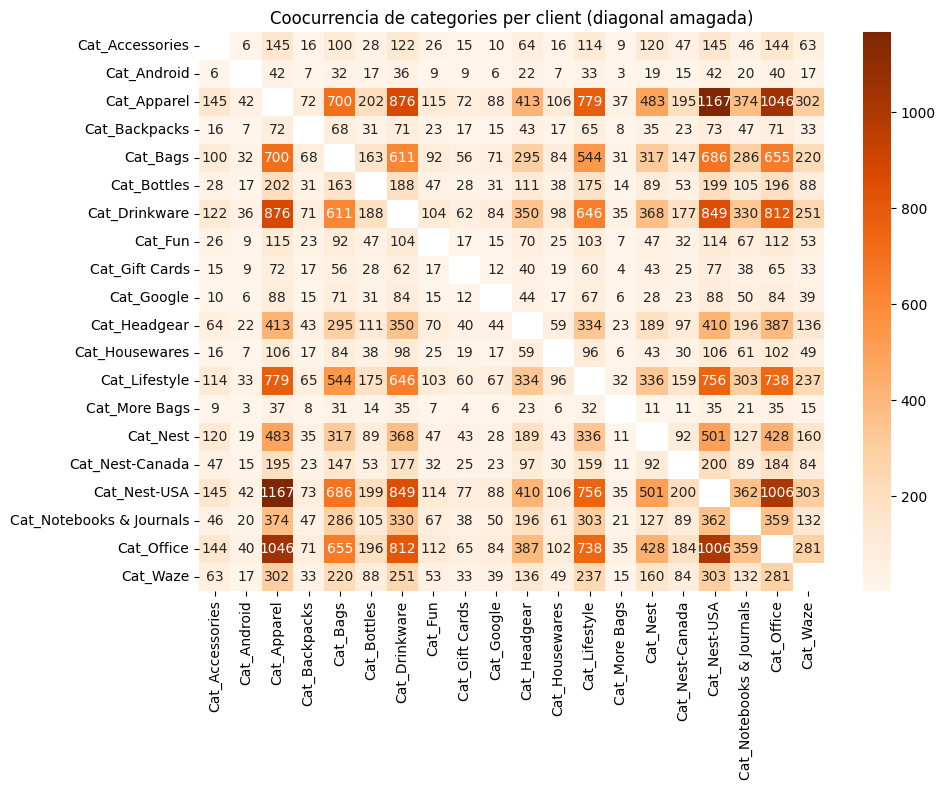

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionem les columnes que representen les categories de producte (codificades en one-hot)
columnes_categories = [col for col in df.columns if col.startswith('Cat_')]
df_categories_clients = df[['CustomerID'] + columnes_categories]

# Generem una matriu binaria que indica si cada client ha comprat almenys un cop cada categoria
matriu_client_categoria = df_categories_clients.groupby('CustomerID')[columnes_categories].sum()
matriu_client_categoria = matriu_client_categoria.applymap(lambda x: 1 if x > 0 else 0)

# Calculem la matriu de coocurrencia: nombre de clients que han comprat conjuntament cada parella de categories
matriu_coocurrencia = matriu_client_categoria.T.dot(matriu_client_categoria)

# Eliminem files o columnes que estiguin completament buides (si n'hi ha)
matriu_coocurrencia = matriu_coocurrencia.loc[
    (matriu_coocurrencia.sum(axis=1) > 0),
    (matriu_coocurrencia.sum(axis=0) > 0)
]

# Substituïm NaNs per 0 per garantir estabilitat a l’hora de visualitzar
matriu_coocurrencia = matriu_coocurrencia.fillna(0)

# Fem una còpia per visualització i ocultem la diagonal (coocurrència d'una categoria amb ella mateixa)
matriu_visual = matriu_coocurrencia.astype(float).copy()
np.fill_diagonal(matriu_visual.values, np.nan)

# Representació gràfica de la matriu de coocurrència
plt.figure(figsize=(10, 8))
sns.heatmap(matriu_visual, annot=True, cmap="Oranges", fmt=".0f", cbar=True)
plt.title("Coocurrencia de categories per client (diagonal amagada)")
plt.tight_layout()
plt.show()


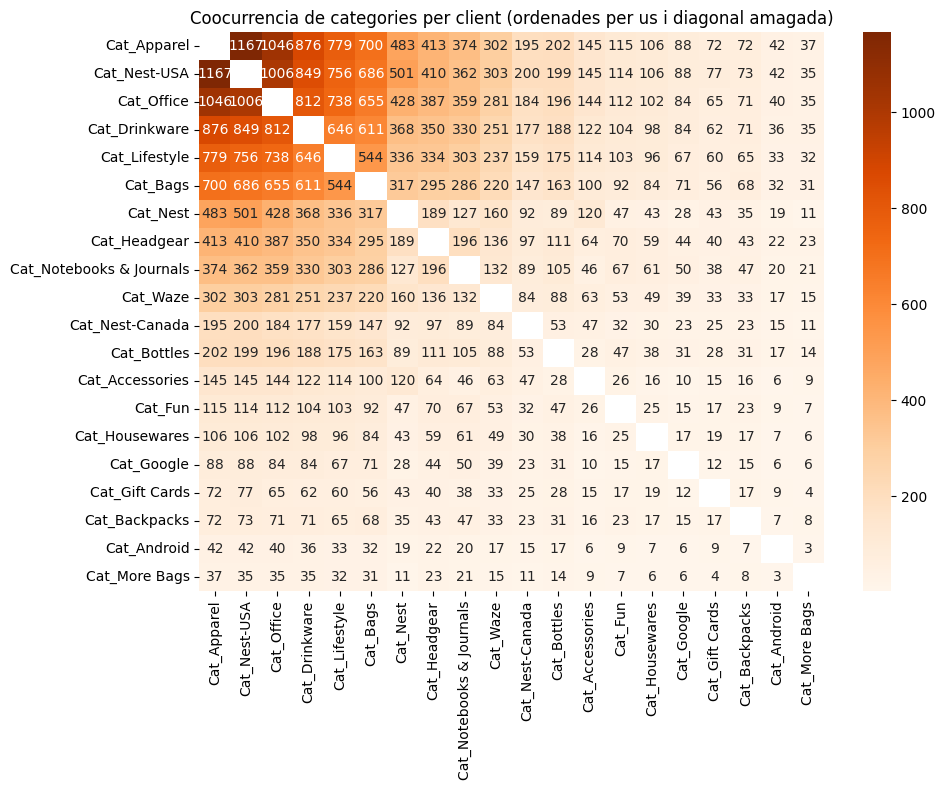

In [3]:
# Ordenem les categories segons el nombre total de clients que han comprat almenys un cop cada categoria
ordre_categories = matriu_client_categoria.sum().sort_values(ascending=False).index.tolist()

# Reordenem la matriu de coocurrencia per tal que les categories més utilitzades apareguin primer
matriu_visual = matriu_coocurrencia.loc[ordre_categories, ordre_categories].astype(float)

# Amaguem la diagonal per facilitar la interpretació (evitem veure coocurrència d’una categoria amb ella mateixa)
np.fill_diagonal(matriu_visual.values, np.nan)

# Visualitzem la nova matriu reordenada
plt.figure(figsize=(10, 8))
sns.heatmap(matriu_visual, annot=True, cmap="Oranges", fmt=".0f", cbar=True)
plt.title("Coocurrencia de categories per client (ordenades per us i diagonal amagada)")
plt.tight_layout()
plt.show()


In [4]:
# Comptem quants clients han comprat almenys un cop cada categoria de producte
clients_per_category = matriu_client_categoria.sum()

# Mostrem per pantalla el nombre total de clients per cada categoria
print("Nombre de clients per categoria:")
print(clients_per_category)


Nombre de clients per categoria:
Cat_Accessories              150
Cat_Android                   42
Cat_Apparel                 1323
Cat_Backpacks                 75
Cat_Bags                     728
Cat_Bottles                  203
Cat_Drinkware                919
Cat_Fun                      118
Cat_Gift Cards                77
Cat_Google                    89
Cat_Headgear                 425
Cat_Housewares               107
Cat_Lifestyle                817
Cat_More Bags                 37
Cat_Nest                     516
Cat_Nest-Canada              205
Cat_Nest-USA                1260
Cat_Notebooks & Journals     383
Cat_Office                  1103
Cat_Waze                     309
dtype: int64


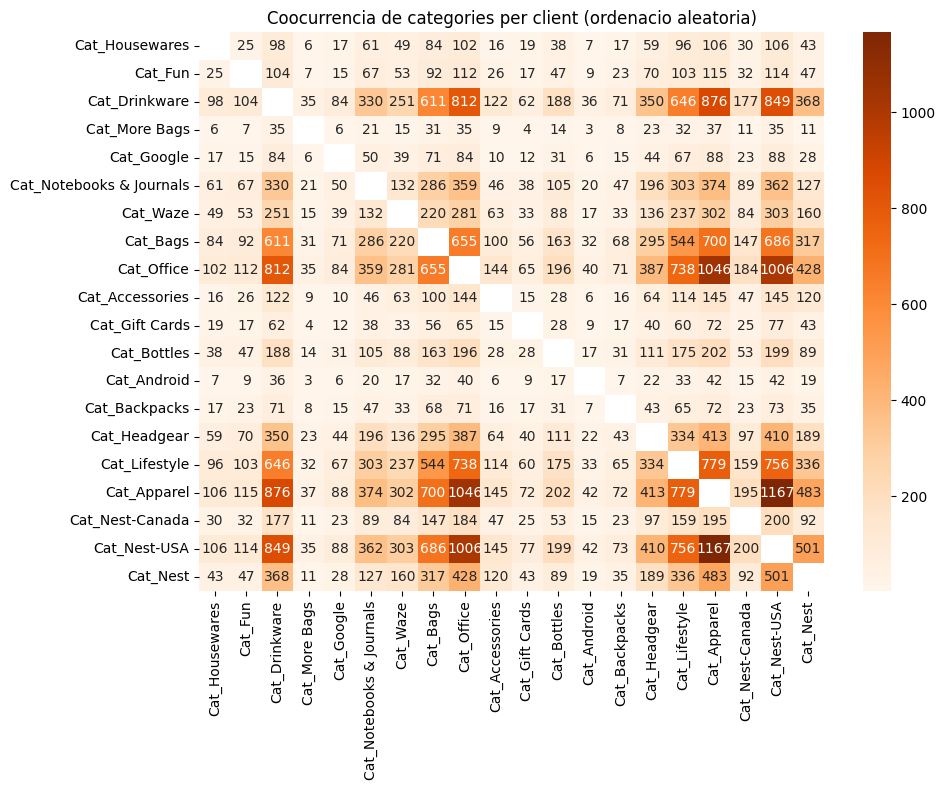

In [5]:
import random

# Generem una ordenacio aleatoria de les categories per fer una comparativa visual
ordre_aleatoria = matriu_coocurrencia.columns.tolist()
random.shuffle(ordre_aleatoria)

# Reordenem la matriu de coocurrencia segons aquest ordre aleatori
matriu_coocurrencia_aleatoria = matriu_coocurrencia.loc[ordre_aleatoria, ordre_aleatoria].astype(float)

# Amaguem la diagonal per no interferir amb la interpretacio visual
np.fill_diagonal(matriu_coocurrencia_aleatoria.values, np.nan)

# Visualitzem la matriu aleatoria per comparar amb l'ordenada per us o per MDS
plt.figure(figsize=(10, 8))
sns.heatmap(matriu_coocurrencia_aleatoria, annot=True, cmap="Oranges", fmt=".0f", cbar=True)
plt.title("Coocurrencia de categories per client (ordenacio aleatoria)")
plt.tight_layout()
plt.show()


# Aplicació de coclustering sobre la matriu client-mes

Es construeix una matriu on cada fila representa un client i cada columna un mes.  
S’aplica coclustering per detectar grups de clients que comparteixen patrons temporals de compra.  
Aquest tipus d’anàlisi pot ser útil per identificar perfils estacionals o clients actius en períodes específics de l’any.


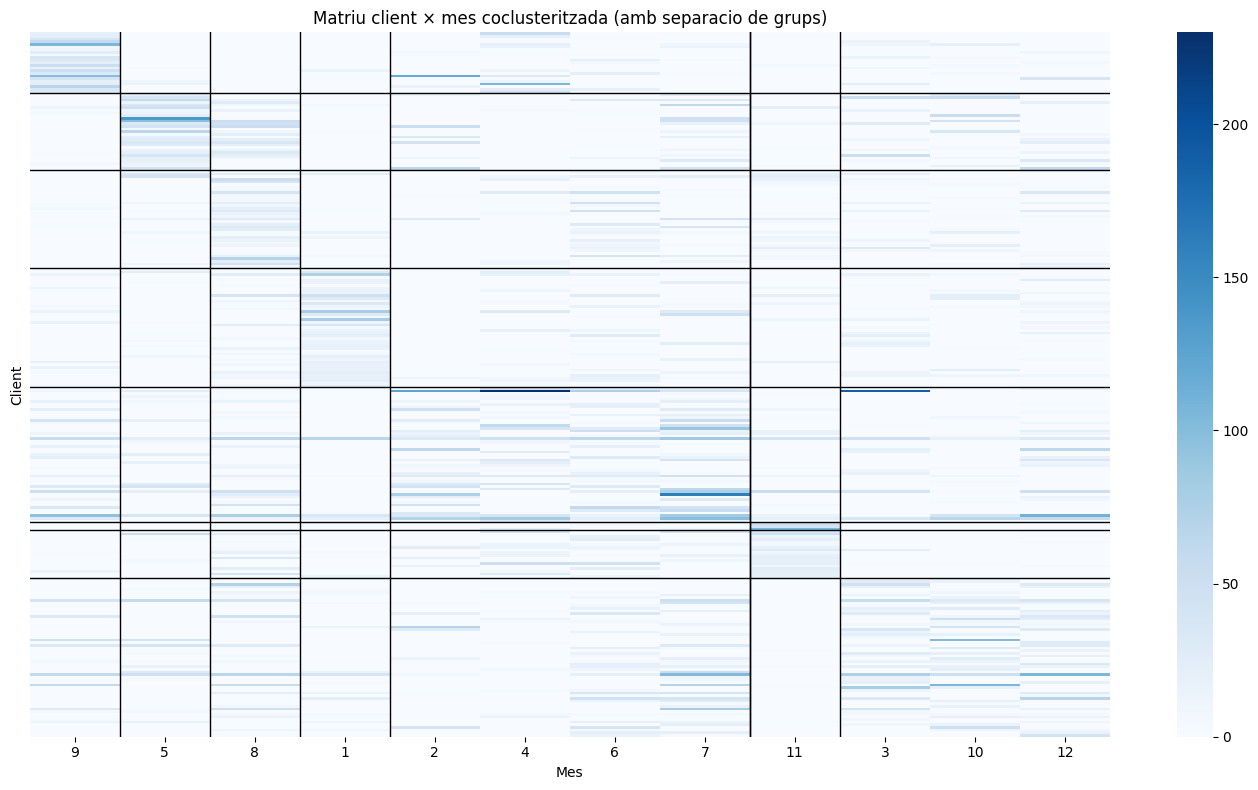

In [6]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Carreguem el dataset preparat
df = pd.read_csv("../data/df_preparat.csv")

# Convertim la columna 'Month' a valor numeric i eliminem registres amb valors nuls
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df = df.dropna(subset=["Month", "CustomerID"])

# Construim la matriu binaria client × mes (compres per mes)
matriu_client_mes = pd.crosstab(df["CustomerID"], df["Month"])

# Filtratge: mantenim només els clients actius en almenys 3 mesos i mesos amb almenys 5 clients
matriu_filtrada = matriu_client_mes.loc[
    matriu_client_mes.gt(0).sum(axis=1) >= 3,
    matriu_client_mes.gt(0).sum(axis=0) >= 5
]

# Apliquem coclustering per agrupar clients i mesos segons patrons comuns de compra
n_clusters = 8
model_cocluster_mes = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model_cocluster_mes.fit(matriu_filtrada)

# Assignem etiquetes de cluster als clients i mesos
matriu_filtrada["Cluster_Client"] = model_cocluster_mes.row_labels_
clusters_mes = pd.DataFrame({
    "Month": matriu_filtrada.columns[:-1],  # excloem Cluster_Client
    "Cluster_Mes": model_cocluster_mes.column_labels_
})

# Exportem els resultats a CSV
matriu_filtrada.reset_index().to_csv("../filesRunTime/client_month_coclusters.csv", index=False)
clusters_mes.to_csv("../filesRunTime/month_coclusters_client_view.csv", index=False)

# Reordenem la matriu per visualitzar millor els coclusters
matriu_reordenada = matriu_filtrada.drop("Cluster_Client", axis=1).iloc[
    model_cocluster_mes.row_labels_.argsort(),
    model_cocluster_mes.column_labels_.argsort()
]

# Calculem les divisions visuals entre coclusters
row_ticks = np.cumsum(np.bincount(model_cocluster_mes.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model_cocluster_mes.column_labels_))[:-1]

# Visualitzem la matriu coclusteritzada
plt.figure(figsize=(14, 8))
ax = sns.heatmap(matriu_reordenada, cmap="Blues", cbar=True, xticklabels=True, yticklabels=False)

# Linias de separacio entre grups de clients i mesos
for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)

plt.title("Matriu client × mes coclusteritzada (amb separacio de grups)")
plt.xlabel("Mes")
plt.ylabel("Client")
plt.tight_layout()
plt.show()


# Aplicació de coclustering sobre la matriu producte-mes

S’inverteix la perspectiva respecte a l’anterior: ara, cada fila representa un producte i cada columna un mes.  
L’objectiu és descobrir productes que segueixen patrons temporals similars (per exemple, llançaments de campanya, productes estacionals...).  
Aquest anàlisi pot ajudar a detectar sinergies temporals entre productes.


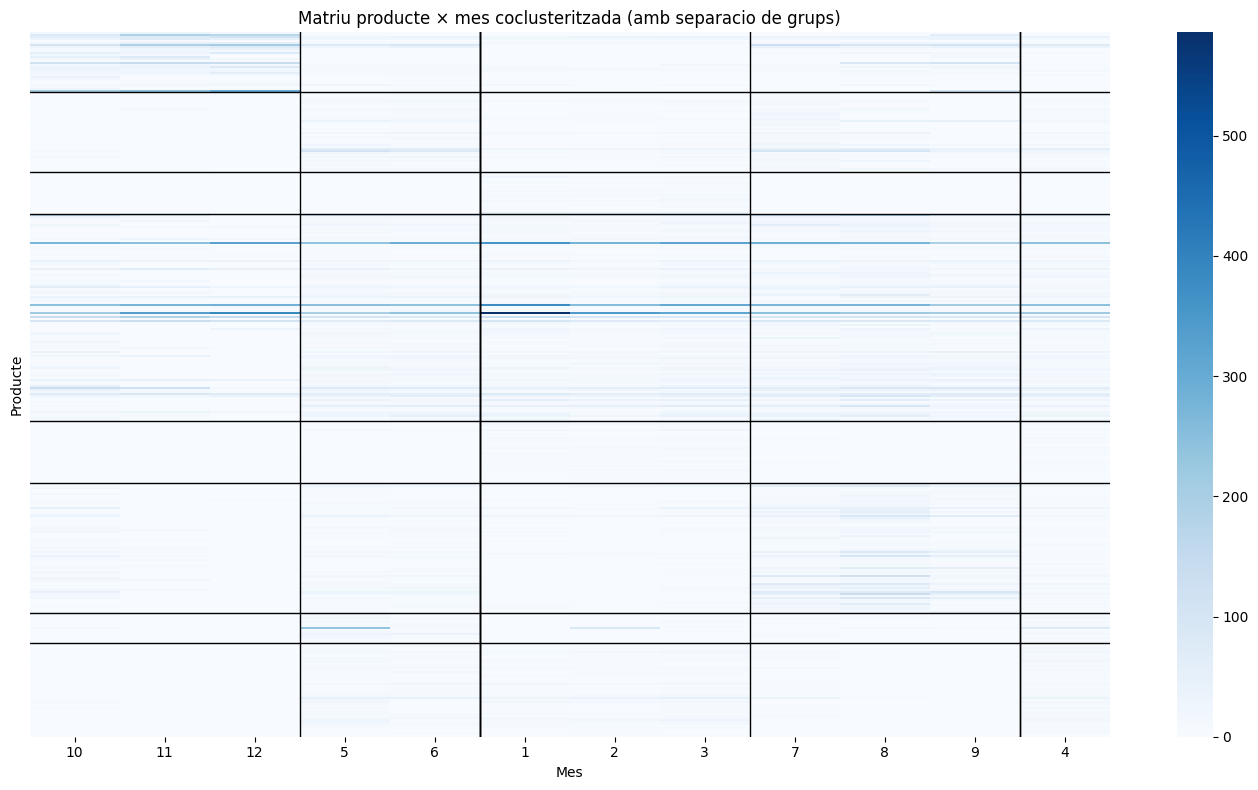

In [7]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Carreguem les dades preparades
df = pd.read_csv("../data/df_preparat.csv")

# Convertim la columna 'Month' a valor numeric i eliminem registres amb valors nuls en 'Month' o 'Product_Description'
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df = df.dropna(subset=["Month", "Product_Description"])

# Construim la matriu producte × mes: nombre de vegades que s'ha comprat cada producte cada mes
matriu_producte_mes = pd.crosstab(df["Product_Description"], df["Month"])

# Filtratge: mantenim només productes actius en almenys 3 mesos i mesos amb almenys 5 productes diferents
matriu_filtrada = matriu_producte_mes.loc[
    matriu_producte_mes.gt(0).sum(axis=1) >= 3,
    matriu_producte_mes.gt(0).sum(axis=0) >= 5
]

# Apliquem l'algoritme de coclustering per agrupar productes i mesos segons el patró de vendes
n_clusters = 8
model_cocluster = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model_cocluster.fit(matriu_filtrada)

# Assignem les etiquetes de clusters als productes i mesos
matriu_filtrada["Cluster_Producte"] = model_cocluster.row_labels_
clusters_mes = pd.DataFrame({
    "Month": matriu_filtrada.columns[:-1],
    "Cluster_Mes": model_cocluster.column_labels_
})

# Exportem els resultats en fitxers CSV
matriu_filtrada.reset_index().to_csv("../filesRunTime/product_month_coclusters.csv", index=False)
clusters_mes.to_csv("../filesRunTime/month_coclusters_product_view.csv", index=False)

# Reordenem la matriu per visualitzar millor els grups formats pel coclustering
matriu_reordenada = matriu_filtrada.drop("Cluster_Producte", axis=1).iloc[
    model_cocluster.row_labels_.argsort(),
    model_cocluster.column_labels_.argsort()
]

# Calculem les posicions de separacio entre coclusters per a la visualitzacio
row_ticks = np.cumsum(np.bincount(model_cocluster.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model_cocluster.column_labels_))[:-1]

# Representacio visual de la matriu coclusteritzada
plt.figure(figsize=(14, 8))
ax = sns.heatmap(matriu_reordenada, cmap="Blues", cbar=True, xticklabels=True, yticklabels=False)

# Afegim línies per separar visualment els grups de productes i mesos
for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)

plt.title("Matriu producte × mes coclusteritzada (amb separacio de grups)")
plt.xlabel("Mes")
plt.ylabel("Producte")
plt.tight_layout()
plt.show()
